In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import gseapy as gp
import textwrap

sc.settings.verbosity = 2
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.4 umap==0.5.7 numpy==1.26.4 scipy==1.15.2 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.6 pynndescent==0.5.13


In [2]:
start = time.perf_counter()

path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_merged_gene_data.h5ad"

adata = sc.read_h5ad(path)

sc.logging.print_memory_usage() 
print(f"Total time: {time.perf_counter() - start:.2f} seconds")

adata

Memory usage: current 2.65 GB, difference +2.65 GB
Total time: 7.19 seconds


AnnData object with n_obs × n_vars = 16367 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'leiden', 'cluster_str', 'S_score', 'G2M_score', 'phase'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_varia

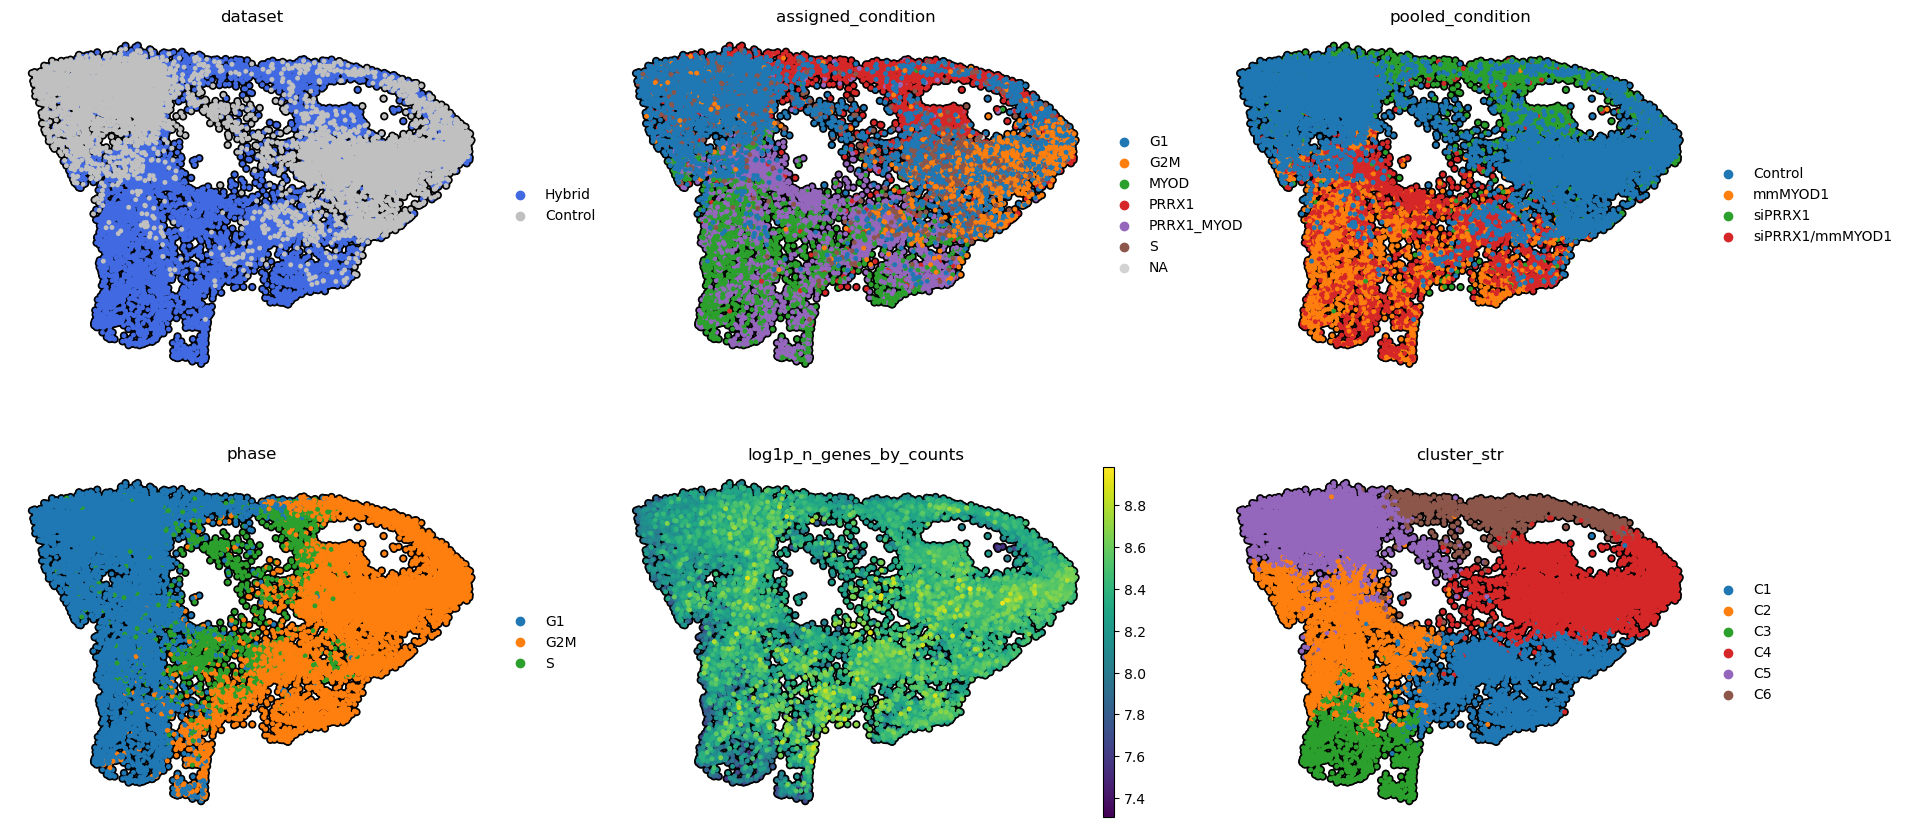

In [3]:
obs_to_plot = ['dataset', 'assigned_condition', 'pooled_condition', 
               'phase', 'log1p_n_genes_by_counts', 'cluster_str']

plt.rcdefaults()
sc.pl.umap(
    adata,
    color=obs_to_plot,
    size=50,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

running Leiden clustering
    finished (0:00:00)


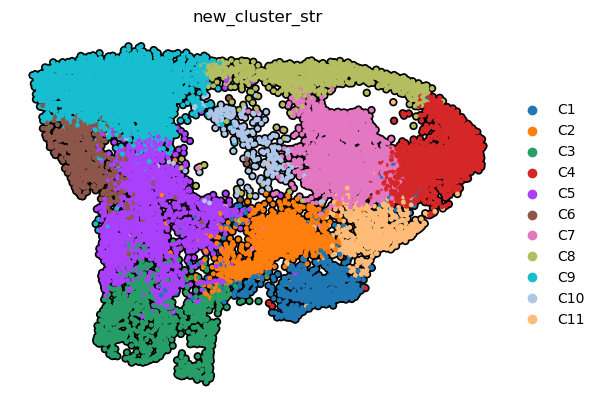

In [6]:
# # sc.pp.neighbors(
# #     adata,
# #     use_rep='X_pca_harmony',
# #     n_neighbors=10,
# # )

# # sc.tl.umap(
# #     adata,
# #     min_dist=0.2
# # )

# sc.tl.leiden(
#     adata,
#     resolution=0.8,
#     flavor="igraph",
#     n_iterations=-1, 
# )

# adata.obs['new_cluster_str'] = adata.obs['leiden'].apply(lambda x: f"C{str(int(x) + 1)}")

# sc.pl.umap(
#     adata,
#     color='new_cluster_str',
#     ncols=1,
#     size=50,
#     add_outline=True,
#     outline_color=('k', 'k'),
#     frameon=False,
#     alpha=1,
# )

In [7]:
sc.tl.rank_genes_groups(
    adata, 
    groupby="cluster_str",
    method='wilcoxon',
    corr_method='benjamini-hochberg',
    use_raw=False,
    layer='log_norm',
    pts=True,
    key_added='cluster_deg',
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    key='cluster_deg',
)

print(deg.shape)
deg.head()

ranking genes
    finished (0:01:06)
(150756, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,C1,ISG20,44.099068,1.905105,0.0,0.0,0.888214,0.474239
1,C1,MT2A,43.234379,0.832291,0.0,0.0,1.000000,1.000000
2,C1,ISG15,42.707260,0.794879,0.0,0.0,1.000000,0.998968
3,C1,IFIT3,41.180180,1.041141,0.0,0.0,1.000000,0.990418
4,C1,BST2,40.717152,1.517866,0.0,0.0,0.925357,0.707378


In [10]:
# filter for significant DEGs
pval_cutoff = 0.01       # p-value threshold
logfc_cutoff = 0.5       # log fold change threshold
print(f"Using p-value cutoff: {pval_cutoff} and log fold change cutoff: {logfc_cutoff}")

sig = deg.copy()

sig['abs_lfc'] = sig['logfoldchanges'].apply('abs')

sig = sig[(sig['abs_lfc'] > logfc_cutoff) & (sig['pvals_adj'] < pval_cutoff)]
print(f"N unique significant DEGs: {sig['names'].nunique()}")
sig.head()

Using p-value cutoff: 0.01 and log fold change cutoff: 0.5
N unique significant DEGs: 9394


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,abs_lfc
0,C1,ISG20,44.099068,1.905105,0.0,0.0,0.888214,0.474239,1.905105
1,C1,MT2A,43.234379,0.832291,0.0,0.0,1.000000,1.000000,0.832291
2,C1,ISG15,42.707260,0.794879,0.0,0.0,1.000000,0.998968,0.794879
3,C1,IFIT3,41.180180,1.041141,0.0,0.0,1.000000,0.990418,1.041141
4,C1,BST2,40.717152,1.517866,0.0,0.0,0.925357,0.707378,1.517866


In [11]:
fpath = "../resources/liu_core_genes.csv"

df = pd.read_csv(fpath)

df.head()

,Fibroblast,Muscle,Circadian,Cell Cycle
0,AKT1,ACTN3,ARNTL,CCNA1
1,API5,ANKRD1,ARNTL2,CCNA2
2,BAG4,ANKRD33,BHLHE41,CCNB1
3,BAK1,BCL9,CLOCK,CCNB2
4,BMI1,BHLHE41,CREBBP,CCNC


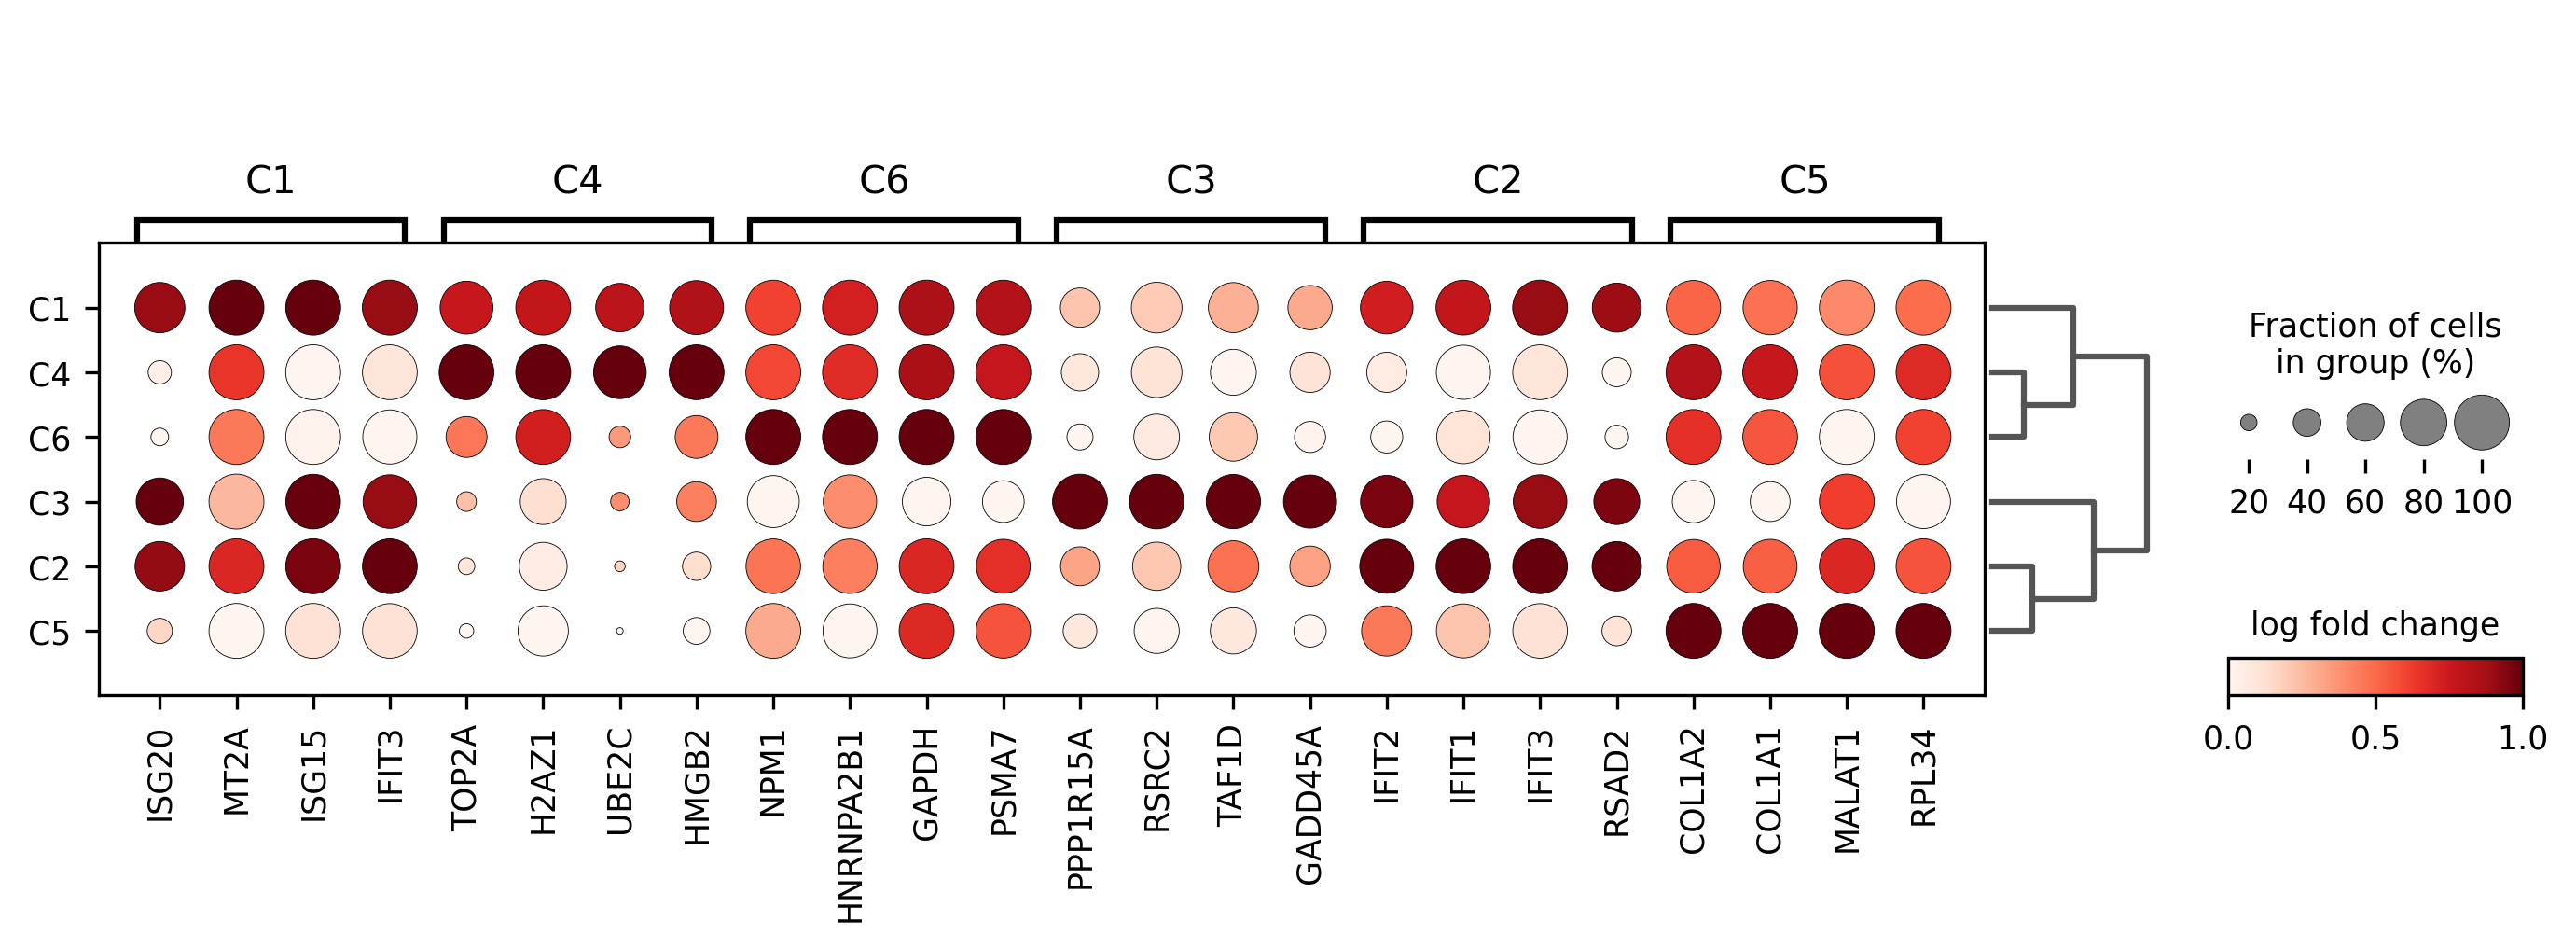

In [17]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    key='cluster_deg',
    values_to_plot='logfoldchanges',
    # var_names=genes_to_plot,
    standard_scale='var',
    n_genes=4,
)

28


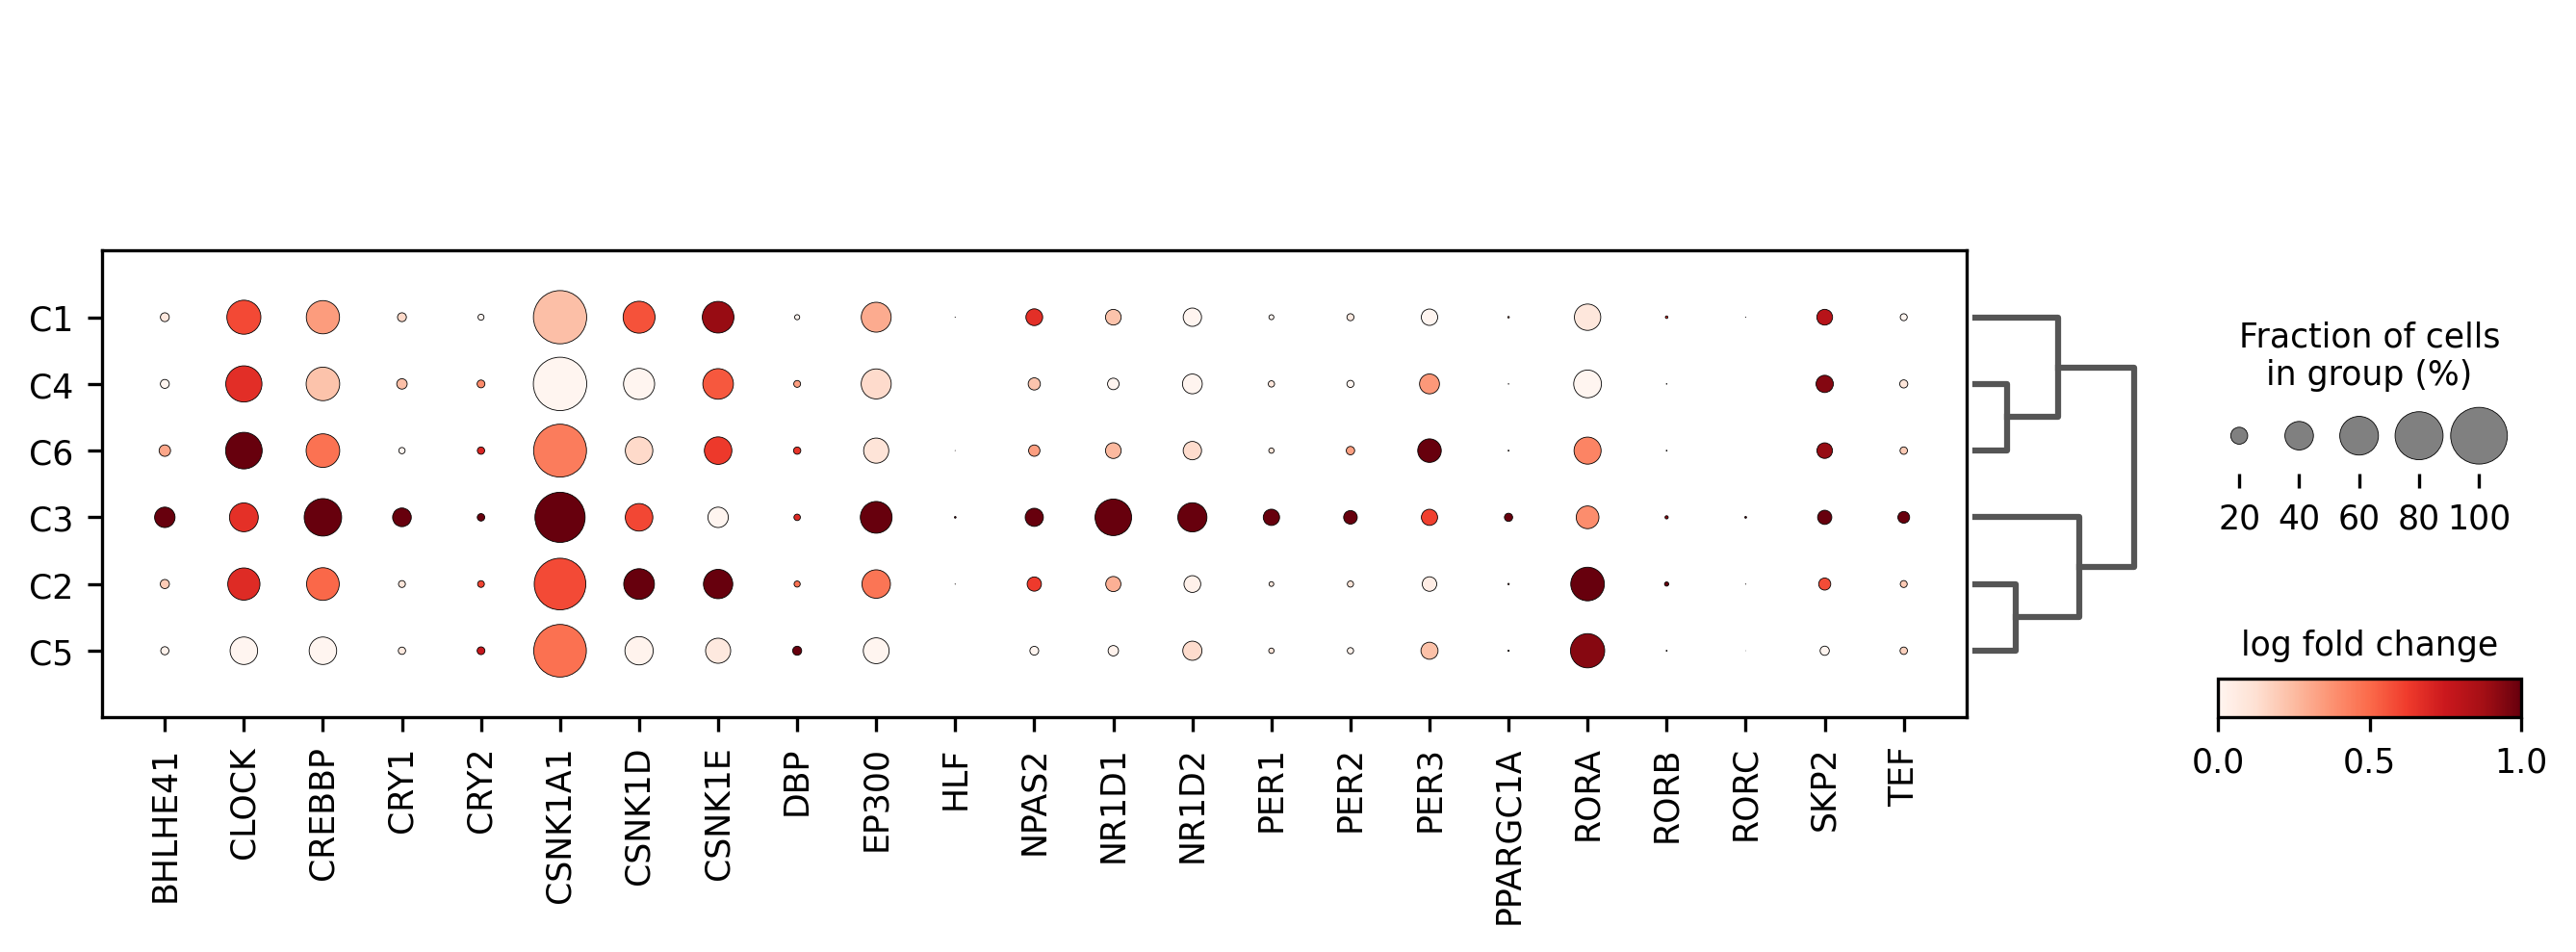

In [14]:
circadian = df['Circadian'].unique()
print(len(circadian))

genes_to_plot = [x for x in circadian if x in adata.var_names]

sc.pl.rank_genes_groups_dotplot(
    adata,
    key='cluster_deg',
    values_to_plot='logfoldchanges',
    var_names=genes_to_plot,
    standard_scale='var',
)

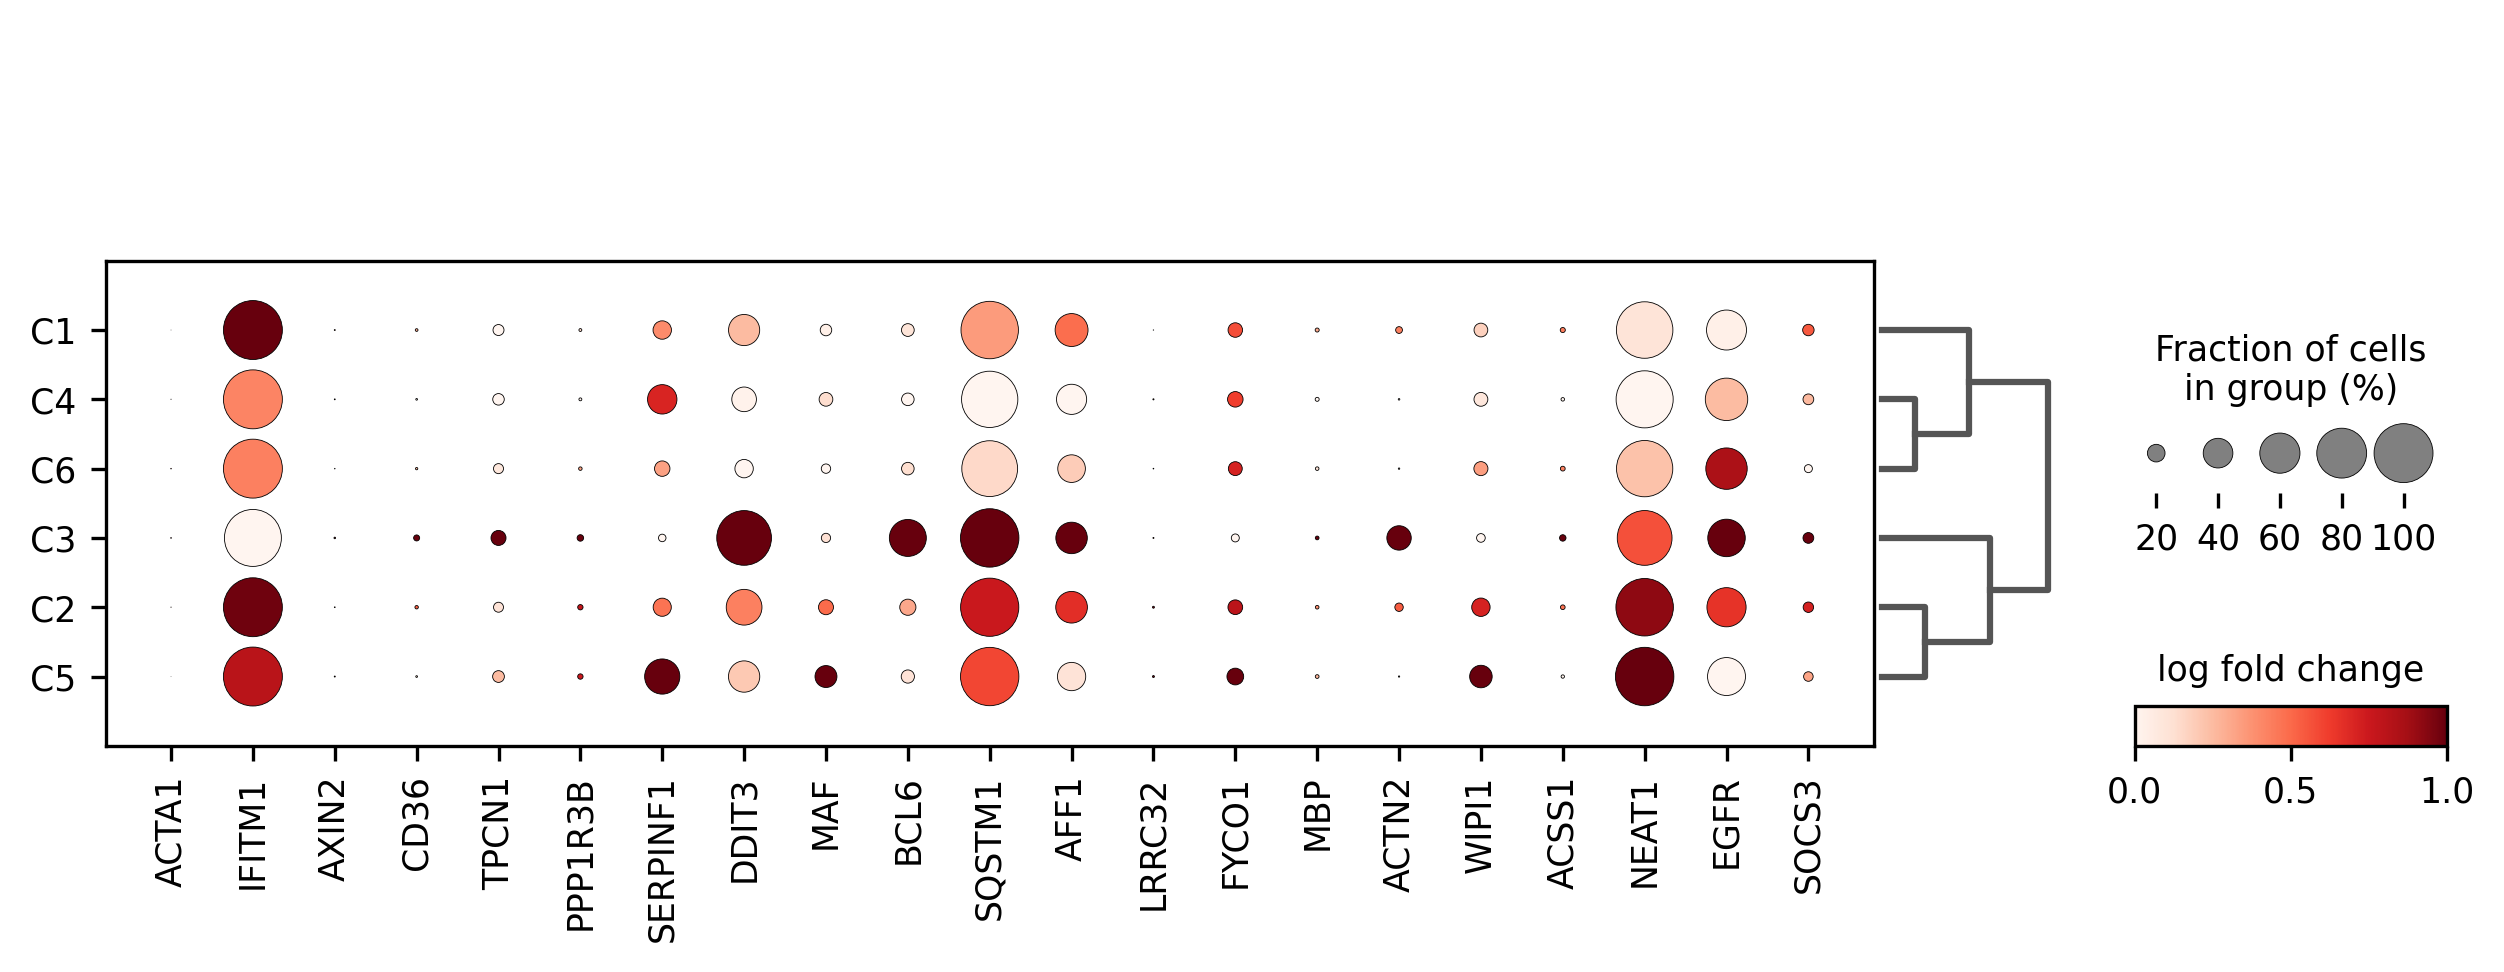

In [18]:
genes = [
    'ACTA1', 'IFITM1', 'AXIN2', 'CD36', 'TPCN1', 'C10orf10', 'PPP1R3B', 'SERPINF1', 'DDIT3', 'MAF', 'TNNI1', 'BCL6', 'TNNT3', 'SQSTM1', 'AFF1', 'MYL1', 'LRRC32', 'FYCO1', 
    'MBP', 'ACTN2', 'WIPI1', 'ACSS1', 'NEAT1', 'EGFR', 'SOCS3',
]  # these are genes from Fig 5 of Liu 2018 paper; SE-P genes (super enhancer promoter ?)

genes_to_plot = [x for x in genes if x in adata.var_names]

sc.pl.rank_genes_groups_dotplot(
    adata,
    key='cluster_deg',
    values_to_plot='logfoldchanges',
    var_names=genes_to_plot,
    standard_scale='var',
)

In [23]:
# get gene annotation info from adata.var
gdf = adata.var[['gene_type', 'mt', 'ribo']].copy()
gdf = gdf.reset_index(names='names')

print(sig.shape)
print(gdf.shape)

# filter sig DEGs for named protein-coding genes
pdf = pd.merge(sig, gdf, how='left', on='names')

pdf = pdf[pdf['gene_type'] == 'protein_coding'] # get only protein-coding genes
pdf = pdf[~pdf['names'].str.startswith(('ENSG', 'MT-'))] # remove unnamed and MT genes

pdf = pdf[pdf['pct_nz_group'] > 0.5] # filter for genes expressed in at least 50% of the group

print(pdf.shape)
print(f"N unique DE protein-coding genes: {pdf['names'].nunique()}")

pdf = pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, True])
pdf.groupby('group', observed=True)[['group', 'names', 'logfoldchanges']].head()

(19623, 9)
(25126, 4)
(3768, 12)
N unique DE protein-coding genes: 2248


,group,names,logfoldchanges
1485,C1,SERPINE2,-1.157899
1490,C1,DCN,-1.115451
1482,C1,NUPR1,-1.084762
1491,C1,COL3A1,-1.017569
1484,C1,LUM,-0.991695
3460,C2,SMC4,-1.841035
3430,C2,PTTG1,-1.659453
3471,C2,H2AZ1,-1.636695
3449,C2,DUT,-1.326271
3414,C2,ANP32E,-1.325675


In [24]:
pdf = pdf.sort_values(by=['group', 'logfoldchanges'], ascending=[True, True])

pdf['rank'] = pdf.groupby('group').cumcount()

pivot_df = pdf.pivot(index='rank', columns='group', values='names')

# Optional: Reset index if desired
pivot_df = pivot_df.reset_index(drop=True)

pivot_df.head()

group,C1,C2,C3,C4,C5,C6
0,SERPINE2,SMC4,COL1A2,IFIT2,STMN1,GBP1
1,DCN,PTTG1,COL1A1,CCL2,CKS2,RIGI
2,NUPR1,H2AZ1,HSP90B1,FILIP1L,ARL6IP1,IRF1
3,COL3A1,DUT,TIMP1,SQSTM1,H2AZ1,EPSTI1
4,LUM,ANP32E,S100A4,TXNIP,ANP32E,SAMD9


In [26]:
pivot_df.head(10)

group,C1,C2,C3,C4,C5,C6
0,SERPINE2,SMC4,COL1A2,IFIT2,STMN1,GBP1
1,DCN,PTTG1,COL1A1,CCL2,CKS2,RIGI
2,NUPR1,H2AZ1,HSP90B1,FILIP1L,ARL6IP1,IRF1
3,COL3A1,DUT,TIMP1,SQSTM1,H2AZ1,EPSTI1
4,LUM,ANP32E,S100A4,TXNIP,ANP32E,SAMD9
5,ADAMTS1,ARL6IP1,SERPINE2,TAF1D,TUBA1B,C1R
6,COL1A1,STMN1,ACTB,IRF1,NASP,GREM1
7,COL1A2,CALU,NME2,NAV3,DNMT1,CTSK
8,DSEL,CKS2,DSTN,IFI27,HMGN2,SAMD9L
9,CITED2,RPA3,PTMA,GLRX,JPT1,TXNIP


Running Enrichment on C1 group with 200 genes using database: GO_Biological_Process_2025...
Significant terms for C1: 129
(alpha = 0.01)


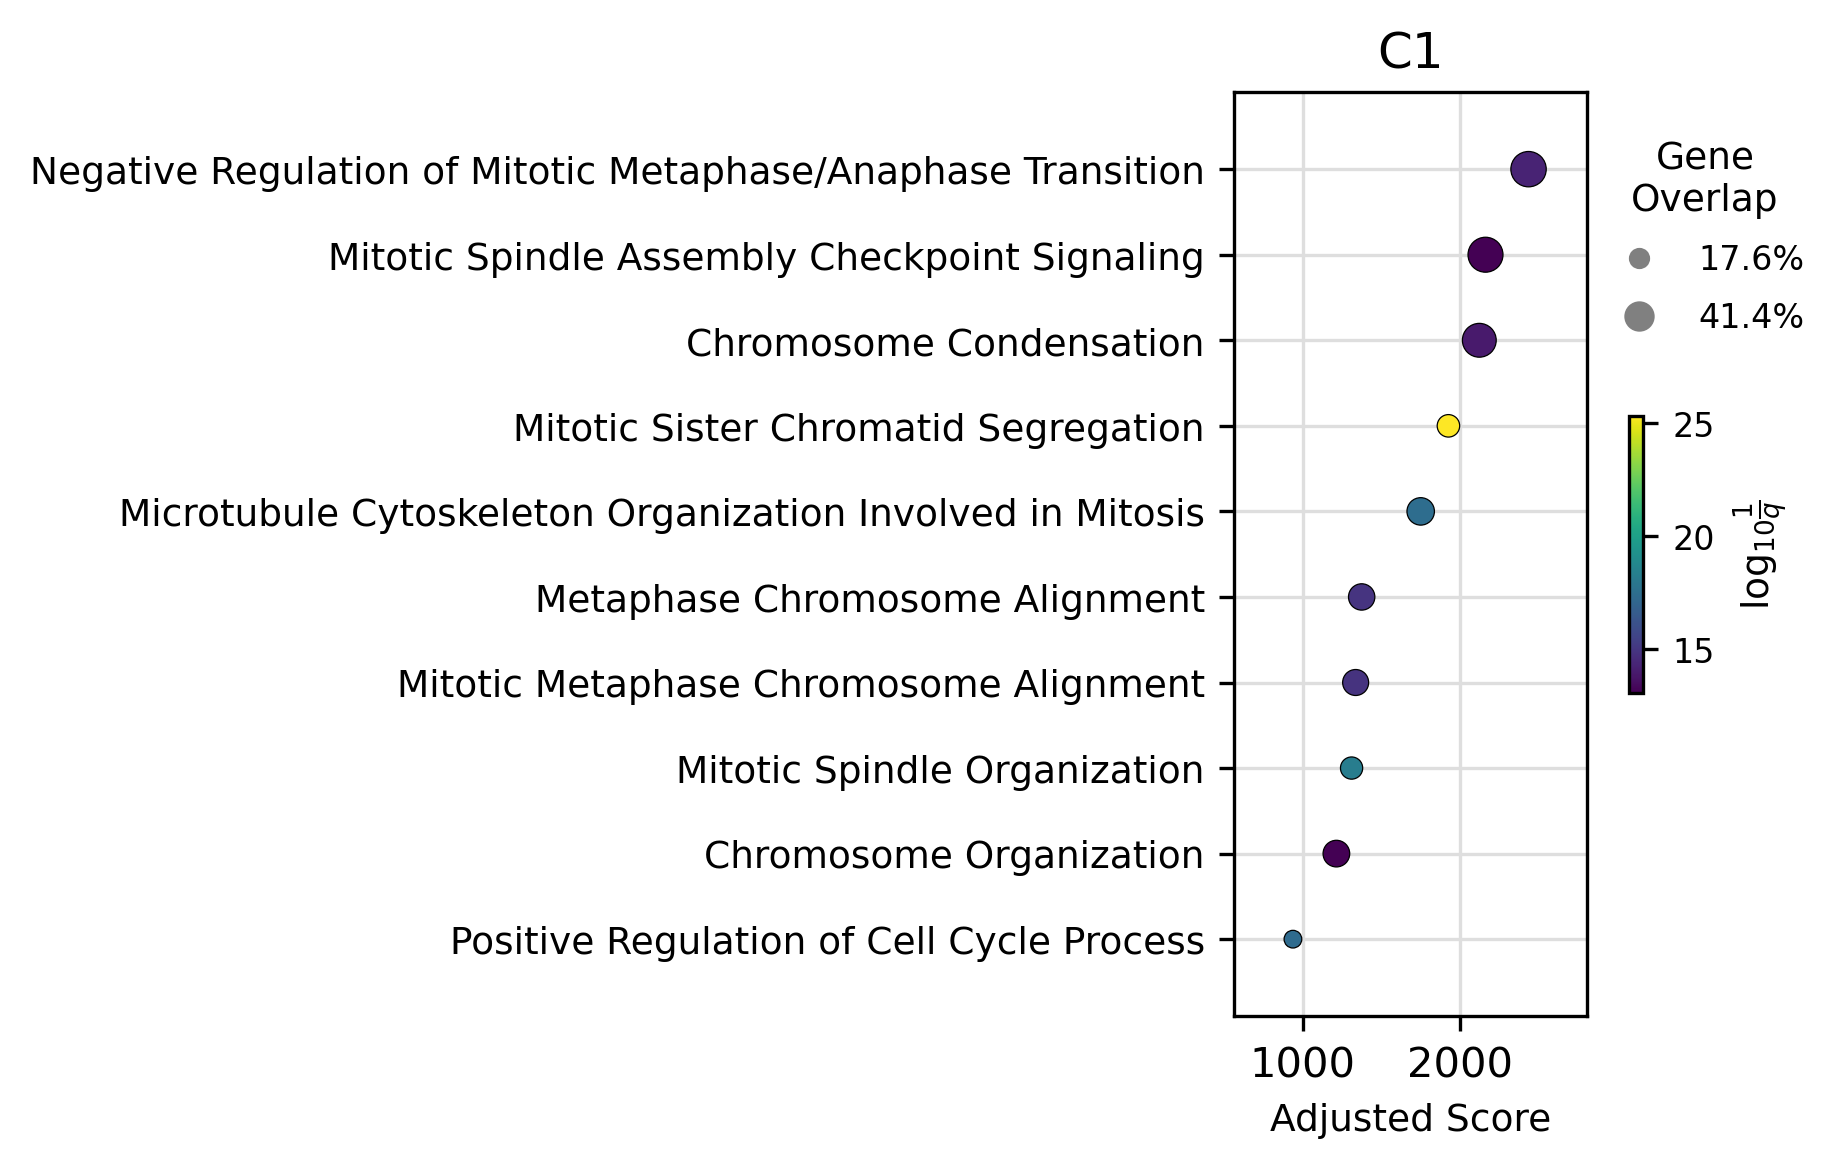

Running Enrichment on C2 group with 200 genes using database: GO_Biological_Process_2025...
Significant terms for C2: 84
(alpha = 0.01)


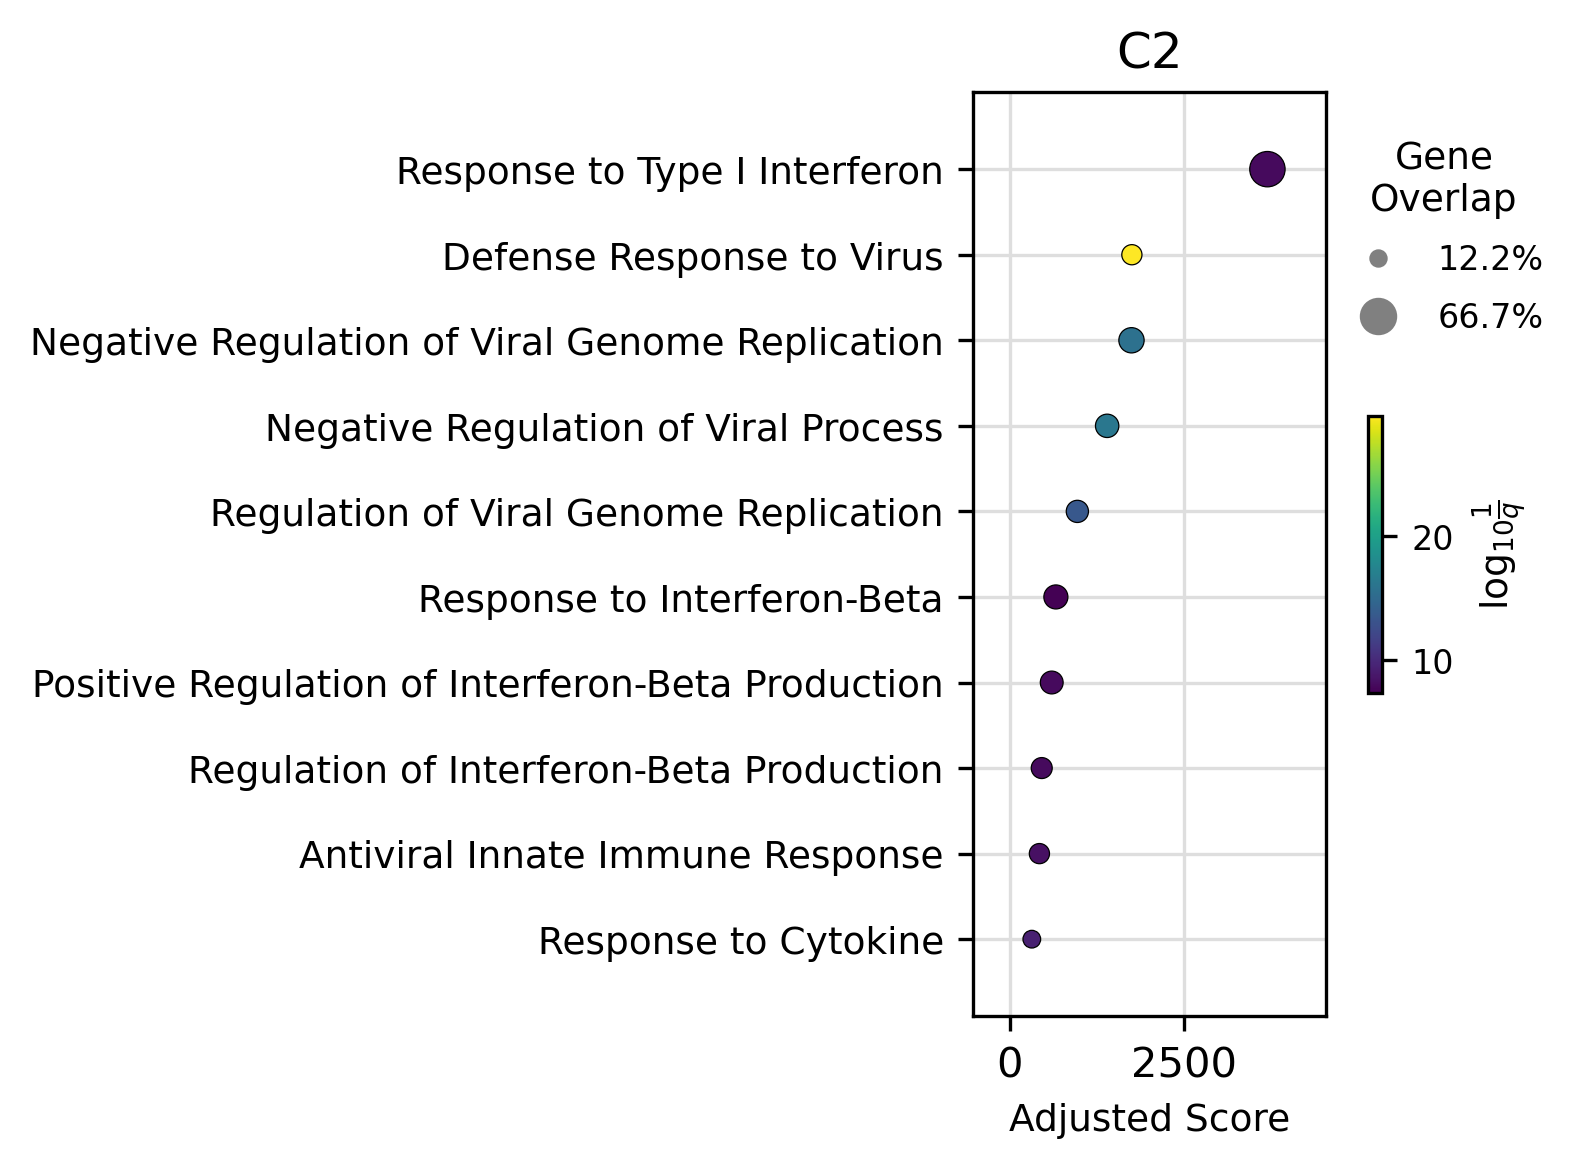

Running Enrichment on C3 group with 200 genes using database: GO_Biological_Process_2025...
Significant terms for C3: 60
(alpha = 0.01)


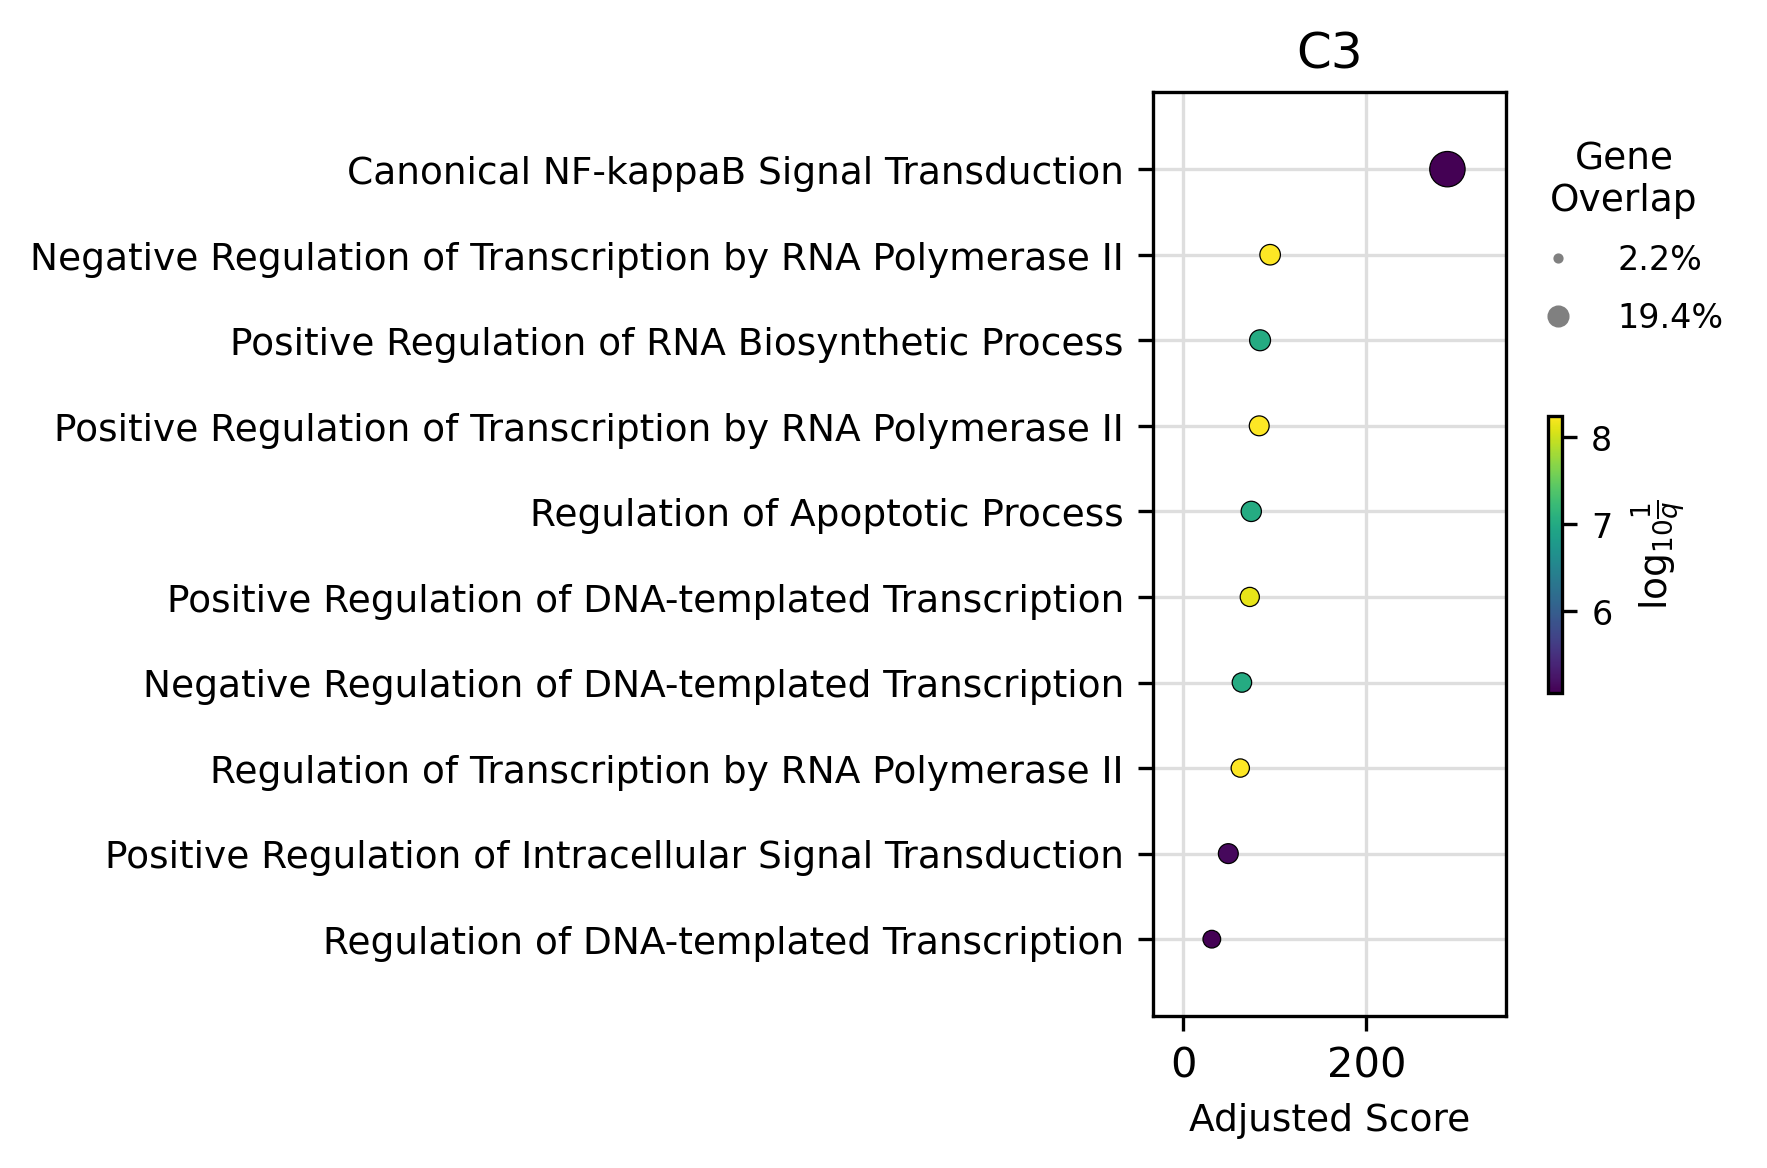

Running Enrichment on C4 group with 200 genes using database: GO_Biological_Process_2025...
Significant terms for C4: 153
(alpha = 0.01)


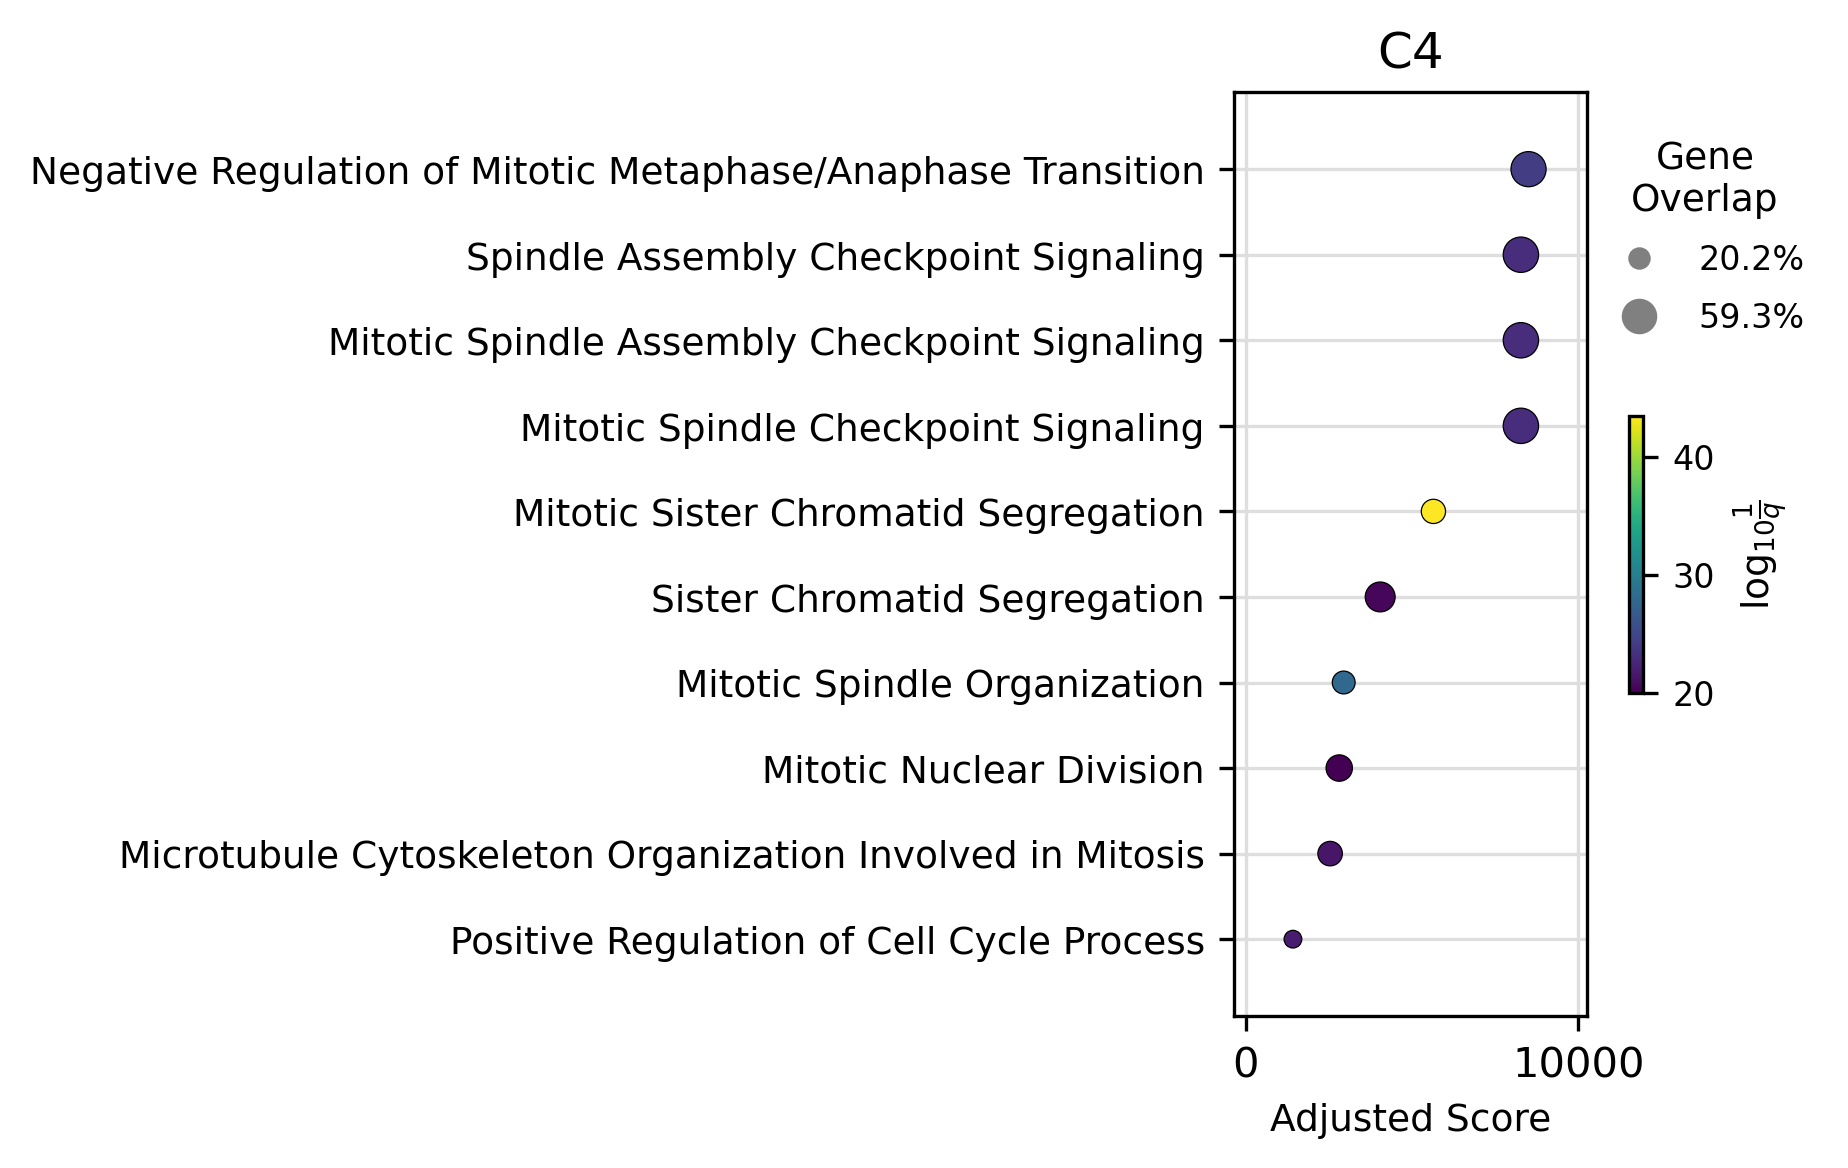

Running Enrichment on C5 group with 200 genes using database: GO_Biological_Process_2025...
Significant terms for C5: 58
(alpha = 0.01)


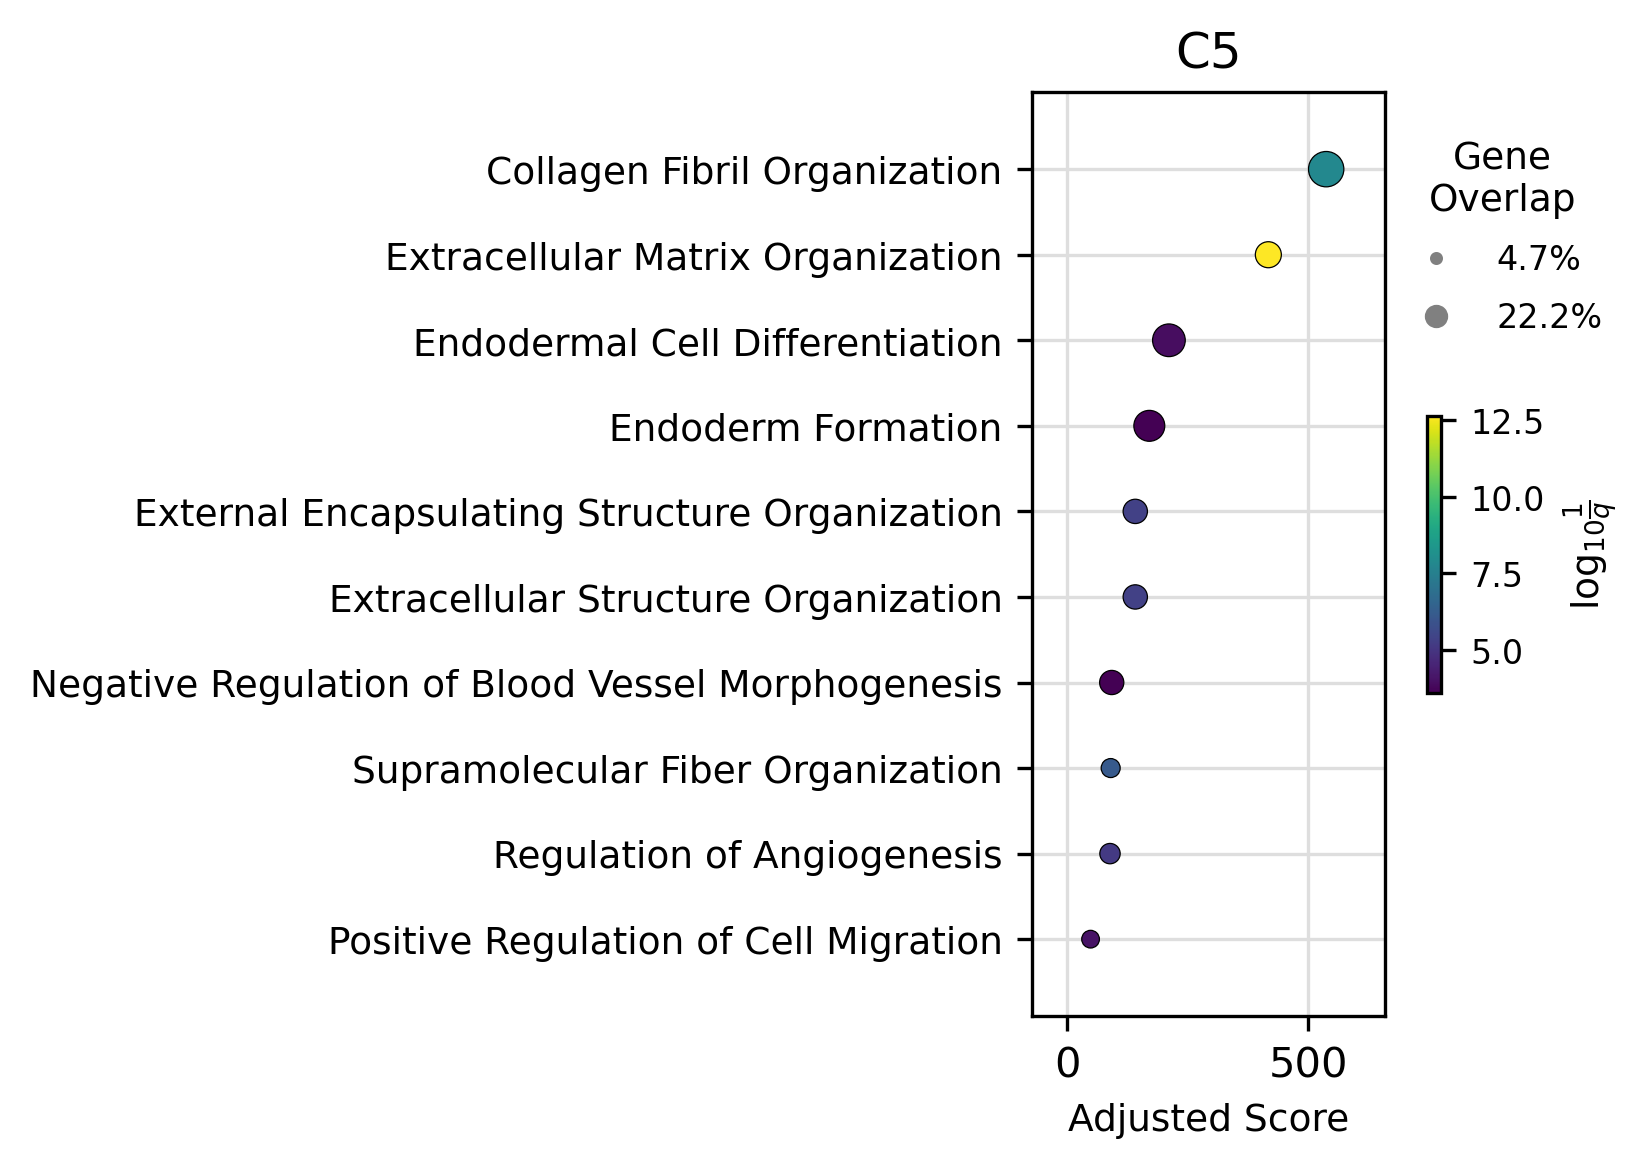

Running Enrichment on C6 group with 200 genes using database: GO_Biological_Process_2025...
Significant terms for C6: 67
(alpha = 0.01)


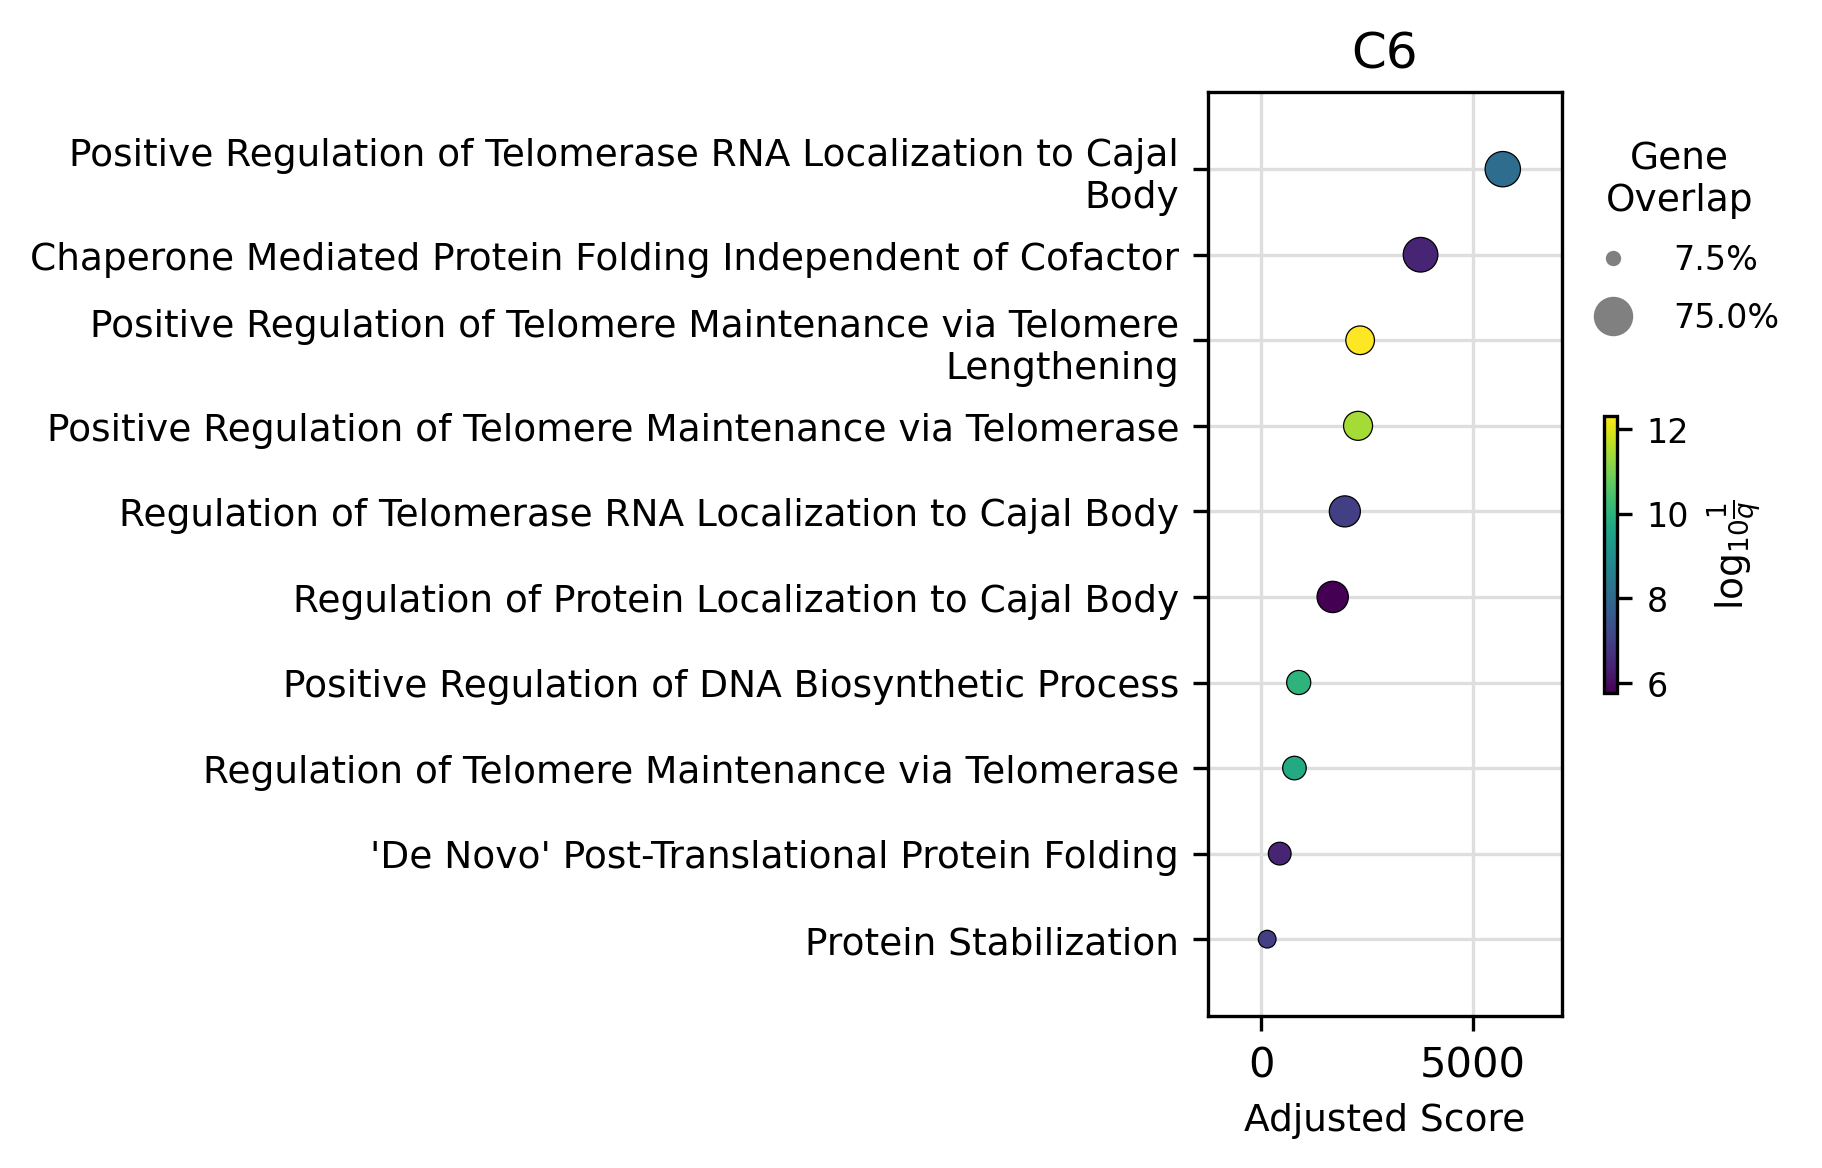

In [32]:
# Define the list of conditions to loop through
conditions_to_plot = pdf.sort_values(by='group')['group'].unique().tolist()

plt.rcParams['figure.dpi'] = 300

n_genes = 200 
database="GO_Biological_Process_2025"
# database="Reactome_Pathways_2024"
# database="KEGG_2021_Human"
# database = "CellMarker_2024"
# database = "TF_Perturbations_Followed_by_Expression"
# database = "WikiPathways_2024_Human"
# database='GO_Molecular_Function_2025'
# database='MSigDB_Hallmark_2020' # interesting
# database='Tabula_Sapiens'
n_terms = 10
alpha = 0.01

# Loop through each condition to generate a separate plot
for condition in conditions_to_plot:
    print(f"Running Enrichment on {condition} group with {n_genes} genes using database: {database}...")

    # Filter pdf for the current condition and get gene list
    tmp = pdf[pdf['group'] == condition]
    tmp = tmp.sort_values(by='logfoldchanges', ascending=False)
    gene_list = tmp['names'].head(n_genes).to_list()


    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=database,
        organism='human', # Or 'mouse' if appropriate for your data
        outdir=None, # Prevents writing results to disk, if not desired
    )
    edf = enr.results.copy()


    # Filter for significant terms
    # Ensure there are significant terms before proceeding to plotting
    if not edf.empty:
        edf = edf[edf['Adjusted P-value'] < alpha].copy()
        print(f"Significant terms for {condition}: {edf['Term'].nunique()}\n(alpha = {alpha})")

        if edf.empty:
            print(f"No significant terms found for condition: {condition}. Skipping plot.")
            continue # Skip to the next condition if no significant terms

        # Create plotting columns
        overlap_split = edf["Overlap"].str.split("/", expand=True).astype(int)
        edf['Overlap_pct'] = (100 * overlap_split[0] / overlap_split[1]).round(1)
        edf['log10_adj_pval'] = np.log10(1 / edf['Adjusted P-value'])
        # Remove (GO:...) and (Reactome:...) identifiers from term names
        edf['Term'] = edf['Term'].str.replace(r'\s\(GO:\d+\)', '', regex=True)
        edf['Term'] = edf['Term'].str.replace(r'\s\(Reactome:R-HSA-\d+\)', '', regex=True)

        # Calculate combined score with adjusted p-val
        edf['adj_score'] = -np.log(edf['Adjusted P-value']) * edf['Odds Ratio']

        # Get top n terms sorted by significance (Adjusted P-value)
        edf = edf.sort_values(by='Adjusted P-value', ascending=True).head(n_terms).copy()

        # Sort by adjusted combined score for plotting (descending)
        edf = edf.sort_values(by='adj_score', ascending=False).copy()

        # --- Plotting Code for current condition ---
        # Create a new figure and axes for each plot in the loop
        fig, ax = plt.subplots(figsize=(2, 4))

        sns.scatterplot(
            data=edf,
            x='adj_score',
            y='Term',
            ec='k', # Edge color
            linewidth=0.3,
            hue='log10_adj_pval', # Color by log10(1/Adjusted P-value)
            palette='viridis', # Color map
            size='Overlap_pct', # Size of points by overlap percentage
            zorder=3, # Ensures scatter points are on top of grid
            ax=ax # Explicitly pass the axes object to seaborn
        )

        # Set plot margins
        x_margin = 0.25
        y_margin = 0.1
        ax.margins(x=x_margin, y=y_margin)

        # Add grid
        ax.grid(
            True,
            c='#DEDEDE', # Grid color
            zorder=0, # Ensures grid is behind scatter points
        )

        # Remove y-axis label as tick labels are descriptive
        ax.set_ylabel("")

        # --- Y-tick label wrapping ---
        original_ylabels = edf['Term'].to_list()
        wrap_width = 60 # Adjust this width as needed for your plot size and text length
        wrapped_ylabels = [textwrap.fill(label, wrap_width) for label in original_ylabels]
        ax.set_yticklabels(wrapped_ylabels, fontsize=9)
        # --- End of Y-tick label wrapping ---

        # Colorbar for log10_adj_pval
        norm = plt.Normalize(edf['log10_adj_pval'].min(), edf['log10_adj_pval'].max())
        sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
        sm.set_array([])
        # `fig.colorbar` is used with `ax` to attach it to the current axes' figure
        cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.09, shrink=0.3)
        cbar.set_label('log$_{10} \\frac{1}{q}$', fontsize='9')
        cbar.ax.tick_params(labelsize=8)

        # Overlap percentage legend
        min_overlap = edf['Overlap_pct'].min()
        max_overlap = edf['Overlap_pct'].max()

        # Scaling for legend handles to match scatterplot point sizes
        scaled_min_size = min_overlap * 3 # Adjust multiplier (3) to match visual size
        scaled_max_size = max_overlap * 3 # Adjust multiplier (3) to match visual size

        legend_handles = [
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{min_overlap:.1f}%',
                       markersize=np.sqrt(scaled_min_size / np.pi), linestyle=''),
            plt.Line2D([0], [0], marker='o', color='gray', label=f'{max_overlap:.1f}%',
                       markersize=np.sqrt(scaled_max_size / np.pi), linestyle='')
        ]

        # Gene Overlap legend setup
        legend = ax.legend(handles=legend_handles, title='Gene\nOverlap',
                            loc='upper right', # Location of the legend
                            bbox_to_anchor=(1.7, 0.98), # Position relative to the axes (adjusted for space)
                            fontsize=8, title_fontsize=9, frameon=False, labelspacing=0.75)

        # Center-align the legend title
        legend_title = legend.get_title()
        legend_title.set_ha('center')

        # Set x-axis label and ticks
        ax.set_xlabel("Adjusted Score", fontsize=9)

        ax.set_title(f"{condition}")

        plt.tight_layout(rect=[0, 0, 1.4, 1])
        plt.show()